## 3D UNet Segmentation

This tutorial provides a practical introduction to training a 3D U-Net/Half U-Net in PyTorch via an aortic segmentation task on the *HVSMR-2.0* dataset[1] (Available at: https://figshare.com/articles/dataset/HVSMR-2_0_orig_/25226360)

It covers how  images and segmentation masks are organised and loaded, how the data are divided for training and evaluation, how the U-Net is configured, and how the model is trained using a segmentation loss. It also shows how to monitor learning through training and validation loss, visually inspect predictions across 3D volumes using GIFs, and finally assess the trained model on an independent test set.

The tutorial uses 3D NIfTI data stored in a single folder. For each patient, the original MRI volume is stored as a *.nii.gz file* and the corresponding segmentation is stored as a separate *_seg.nii.gz file*. The segmentation contains multiple anatomical labels: in this tutorial, only label 5, corresponding to the aorta, is selected and converted into a binary mask.

Before training, the MRI volumes are normalized and both images and masks are downsampled to 128 × 128 × 128 voxels and saved as .npy files for the subsequent steps.


### 1. Import dependencies

We start by importing the libraries and functions needed for the tutorial.

Link to the library used to implement the U-Net architecture and the loss function: https://mrphys.github.io/im2sim/

In [35]:
import torch
import torch.nn.functional as F
import glob
from pathlib import Path
import pyvista as pv
import im2sim
import numpy as np
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from im2sim.models import UNet, HalfUNet
from im2sim.configs import UNetConfig, HalfUNetConfig, ImageConvBlockConfig
import wandb
from im2sim.losses import DiceLoss
import random 
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import imageio.v2 as imageio
import numpy as np
import matplotlib.pyplot as plt
import os
import nibabel as nib

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

### 2. Prepare Data

First we need to define the folder containing the images and the corresponding segmentation masks (change the path depending on your data). In this dataset, the images and masks are stored in the same folder, with the masks identified by _seg in the file name.

In [36]:
data_dir = Path("resources/hvsmr")

image_files = sorted(
    data_dir.glob("pat*_orig.nii.gz")
)

mask_files = sorted(
    data_dir.glob("pat*_orig_seg.nii.gz")
)

Then, we can check that every image has a corresponding mask and every mask has a corresponding image, so that we can create a Dataset containing only valid image-mask pairs.

In [37]:
image_names = set(
    f.name.replace("_orig.nii.gz", "")
    for f in image_files
)

mask_names = set(
    f.name.replace("_orig_seg.nii.gz", "")
    for f in mask_files
)

missing_masks = sorted(image_names - mask_names)
missing_images = sorted(mask_names - image_names)

print("Images without masks:")
for f in missing_masks:
    print(f)

print("\nMasks without images:")
for f in missing_images:
    print(f)

files = sorted(image_names & mask_names)

print("\nValid image-mask pairs:", len(files))

Images without masks:

Masks without images:

Valid image-mask pairs: 60


### 3. Normalize and downsample

Before defining the Dataset, we preprocess the data and save the processed images and masks in separate folders.

This is needed because the original MRI volumes have different sizes, high spatial resolution, and non-normalized intensity values. We therefore select only label 5, corresponding to the aorta, normalize the MRI, and resize both image and mask to 128 × 128 × 128.

The processed data are then saved as .npy files so these operations only need to be performed once.

In [38]:
processed_image_dir = Path("resources/hvsmr/images")
processed_mask_dir = Path("resources/hvsmr/masks")

processed_image_dir.mkdir(parents=True, exist_ok=True)
processed_mask_dir.mkdir(parents=True, exist_ok=True)

for patient in files:

    image_path = data_dir / f"{patient}_orig.nii.gz"
    mask_path = data_dir / f"{patient}_orig_seg.nii.gz"

    image = nib.load(image_path).get_fdata()
    mask = nib.load(mask_path).get_fdata()

    # Keep only label 5 = aorta
    mask = (mask == 5).astype(np.float32)

    # Normalize MRI
    image = (
        image - image.mean()
    ) / image.std()

    image = torch.tensor(
        image,
        dtype=torch.float32
    )

    mask = torch.tensor(
        mask,
        dtype=torch.float32
    )

    image = image.unsqueeze(0).unsqueeze(0)
    mask = mask.unsqueeze(0).unsqueeze(0)

    # Downsample image
    image = F.interpolate(
        image,
        size=(128, 128, 128),
        mode="trilinear",
        align_corners=False
    )

    # Downsample mask
    mask = F.interpolate(
        mask,
        size=(128, 128, 128),
        mode="nearest"
    )

    image = image.squeeze()
    mask = mask.squeeze()

    np.save(
        processed_image_dir / f"{patient}.npy",
        image.numpy()
    )

    np.save(
        processed_mask_dir / f"{patient}.npy",
        mask.numpy()
    )

### 4. Define Dataset

We then define the Dataset. Its purpose is to tell PyTorch how our data are organised and how to retrieve one image together with its corresponding mask.

The Dataset receives three pieces of information: the list of patient names that belong to the dataset, the folder containing the processed images, and the folder containing the processed masks.
1. Stores the information needed to find the data.
The Dataset saves the list of patient names and the locations of the image and mask folders. It does not load all the data immediately; it just keeps track of where each processed image and mask can be found.
2. Defines how many samples are in the Dataset.
This tells PyTorch how many image-mask pairs are available.
3. Defines how to load one sample.
The **getitem** function takes the position of one sample, finds the corresponding preprocessed image and mask, loads them from the .npy files, converts them into PyTorch tensors, adds the channel dimension, and returns the image together with its matching ground-truth mask.

In [39]:
class SegmentationDataset(Dataset):

    def __init__(self, files, image_dir, mask_dir):

        self.files = files
        self.image_dir = Path(image_dir)
        self.mask_dir = Path(mask_dir)

    def __len__(self):

        return len(self.files)

    def __getitem__(self, idx):

        patient = self.files[idx]

        image_path = self.image_dir / f"{patient}.npy"
        mask_path = self.mask_dir / f"{patient}.npy"

        image = np.load(image_path)
        mask = np.load(mask_path)

        image = torch.tensor(
            image,
            dtype=torch.float32
        )

        mask = torch.tensor(
            mask,
            dtype=torch.float32
        )
        
        image = image.unsqueeze(0)
        mask = mask.unsqueeze(0)

        return image, mask

### 5. Split into train / validation / test

We divide the data into training, validation, and test sets so that we can train the model, tune/check its performance during development, and finally evaluate it on unseen data.

For the data used in this tutorial, there is only one image per patient, so the dataset can be randomly split into training, validation, and test sets at the file level. However, if your dataset contains multiple images or files from the same patient, you should split the data by patient rather than by individual file. This prevents images from the same patient appearing in different sets, which would cause data leakage and could make the model performance appear better than it really is.

In [40]:
# 80% train, 5% validation, 15% test
random.seed(42)
random.shuffle(files)

n_total = len(files)

n_train = int(0.80 * n_total)
n_test = int(0.15 * n_total)

train_files = files[:n_train]
test_files = files[n_train:n_train + n_test]
val_files = files[n_train + n_test:]

Using these three file lists, we then create separate Dataset objects for training, validation, and testing.

In [41]:
train_dataset = SegmentationDataset(
    train_files,
    processed_image_dir,
    processed_mask_dir
)

val_dataset = SegmentationDataset(
    val_files,
    processed_image_dir,
    processed_mask_dir
)

test_dataset = SegmentationDataset(
    test_files,
    processed_image_dir,
    processed_mask_dir
)

Using the three Dataset objects, we then create a DataLoader for training, validation, and testing. The DataLoaders retrieve the samples from each Dataset in batches; here *batch_size=1* means one 3D volume at a time. We shuffle the training data to vary the order seen by the model, while validation and test data are kept in a fixed order.

In [42]:
train_loader = DataLoader(
    train_dataset,
    batch_size=1,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=1,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False
)

Before moving on the actual model, as an additional check, we can print how many files are assigned to each split. We also compare the total number of valid files with the sum of train, validation, and test files to confirm that no data were lost during the split.

In [80]:
print(f"Train: {len(train_files)}")
print(f"Validation: {len(val_files)}")
print(f"Test: {len(test_files)}")

print(f"N of files before split: {len(files)}")
print(
    f"N of files after split: "
    f"{len(train_files) + len(val_files) + len(test_files)}"
)

Train: 48
Validation: 3
Test: 9
N of files before split: 60
N of files after split: 60


It is also useful to visualize one sample returned by the DataLoader. This allows us to check that the images and masks are being loaded correctly

Image batch shape: torch.Size([1, 1, 128, 128, 128])
Mask batch shape: torch.Size([1, 1, 128, 128, 128])


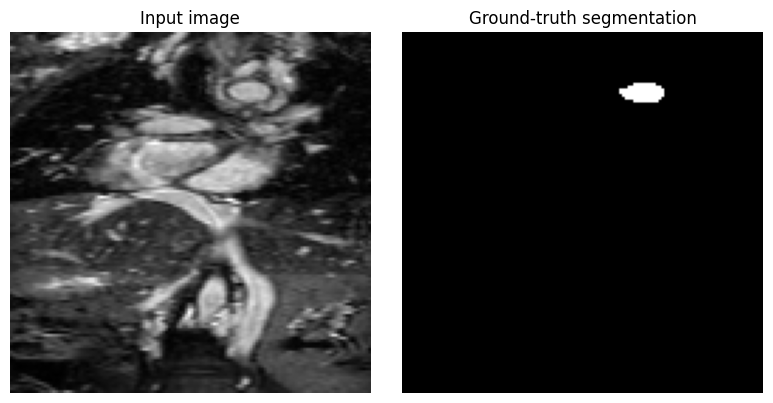

In [44]:
images, masks = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Mask batch shape:", masks.shape)

image = images[0, 0].cpu().numpy()
mask = masks[0, 0].cpu().numpy()

slice_idx = image.shape[0] // 2

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].imshow(image[slice_idx], cmap="gray")
axes[0].set_title("Input image")
axes[0].axis("off")

axes[1].imshow(mask[slice_idx], cmap="gray")
axes[1].set_title("Ground-truth segmentation")
axes[1].axis("off")

plt.tight_layout()
plt.show()

### 6. Build the model and define the loss

**UNetConfig** specifies how the U-Net is built. The *filters=[32, 64, 128]* define how many feature channels are used at the different levels of the network, while the encoder and decoder blocks each contain three convolutional layers with *ReLU* activation. The output block produces a single output channel and applies a *sigmoid* activation, so the final prediction is a value between 0 and 1 for each voxel.

The model is then created with *in_channels=1* because each input volume has one channel, *out_channels=1* because we are predicting one binary segmentation mask, and *rank=3* because we are working with 3D volumes. Finally, **.to(device)** moves the model to the selected device, usually the GPU if available.

In [52]:
cfg = UNetConfig(
    filters=[32, 64, 128],
    encoder_block_cfg=ImageConvBlockConfig(
        depth=3,
        activation="ReLU"
    ),
    decoder_block_cfg=ImageConvBlockConfig(
        depth=3,
        activation="ReLU"
    ),
    out_block_cfg=ImageConvBlockConfig(
        depth=1,
        activation="ReLU",
        out_activation="sigmoid"
    )
)

model = UNet(
    in_channels=1,
    out_channels=1,
    rank=3,
    cfg=cfg
).to(device)

criterion = DiceLoss()

**DiceLoss()** is used as the loss function. It measures the overlap between the predicted segmentation and the ground-truth mask, so training will try to maximise their overlap.

Alternatively, we can use a **HalfUNet** instead of a standard U-Net. The main difference is that, instead of defining a list of filters for the different levels of the network, we define the number of hidden channels, which controls how many features the network uses internally. A HalfUNet also does not have the full decoder part of the standard U-Net, so the architecture is simpler. The rest of the workflow stays the same.

In [46]:
cfg = HalfUNetConfig(
           hidden_channels=64,
           n_levels=3,
           encoder_block_cfg=ImageConvBlockConfig(depth=3, activation="ReLU"),
           out_block_cfg=ImageConvBlockConfig(depth=1, activation="ReLU", out_activation="sigmoid")
      )

model = HalfUNet(
       rank=3,
       in_channels=1,
       out_channels=1,
       cfg=cfg,
   ).to(device)

criterion = DiceLoss()

### 7. Write training/inference loop 

We now train the model using the training set and evaluate it on the validation set after each epoch, while storing both losses to monitor learning over time.

Every 50 epochs, we also apply the current model to the test set and use the GIF functions to create an animated comparison between the predicted segmentation and the ground-truth segmentation across the slices of the 3D volume.

The generated GIFs are saved locally in a dedicated folder (*segmentation_gifs*), so that we can visually compare how the model predictions change during training. The following code is neeed for the generation and saving of the GIFs.

In [53]:
colors = {
    1: (1.0, 0.0, 0.0, 0.35),
    2: (0.0, 1.0, 0.0, 0.35),
    3: (0.0, 0.0, 1.0, 0.35),
    4: (1.0, 1.0, 0.0, 0.35),
    5: (1.0, 0.0, 1.0, 0.35),
    6: (0.0, 1.0, 1.0, 0.35),
}

def labels_to_rgba(label_slice, colors):
    rgba = np.zeros((*label_slice.shape, 4), dtype=np.float32)

    for cls_id, color in colors.items():
        mask = (label_slice == cls_id)
        rgba[mask, :3] = color[:3]
        rgba[mask, 3] = color[3]

    return rgba

def save_comparison_gif(input_vol, pred_seg, true_seg, filename="comparison.gif"):
    """
    input_vol: [H, D, W]
    pred_seg:  [H, D, W] class labels
    true_seg:  [H, D, W] class labels
    """
    out_dir = os.path.dirname(filename)
    if out_dir:
        os.makedirs(out_dir, exist_ok=True)

    frames = []
    num_slices = input_vol.shape[1]  # scroll along D

    for i in range(num_slices):
        fig, axes = plt.subplots(1, 2, figsize=(8, 4))

        input_slice = np.transpose(input_vol[:, i, :])
        pred_slice = np.transpose(pred_seg[:, i, :])
        true_slice = np.transpose(true_seg[:, i, :])

        pred_rgba = labels_to_rgba(pred_slice, colors)
        true_rgba = labels_to_rgba(true_slice, colors)

        axes[0].imshow(input_slice, cmap="gray")
        axes[0].imshow(pred_rgba, interpolation="none")
        axes[0].set_title(f"Pred Seg {i}")
        axes[0].axis("off")

        axes[1].imshow(input_slice, cmap="gray")
        axes[1].imshow(true_rgba, interpolation="none")
        axes[1].set_title(f"GT Seg {i}")
        axes[1].axis("off")

        fig.canvas.draw()
        frame = np.asarray(fig.canvas.buffer_rgba()).copy()
        frames.append(frame)
        plt.close(fig)

    imageio.mimsave(filename, frames, duration=0.2, loop=0)
    return filename

In [ ]:
gif_dir = Path("segmentation_gifs")
gif_dir.mkdir(parents=True, exist_ok=True)

Here we start with the actual training loop. 

We first define the **optimizer**, which controls how the model weights are updated during training. Here we use *Adam* with a learning rate of 1e-3. We also set the number of training epochs to 200 and create two lists to store the training and validation losses.

For each epoch, the model is first put in training mode with **model.train()**. Each batch of images and masks is moved to the selected device, the previous gradients are cleared, and the model produces a prediction. The loss is then calculated by comparing the prediction with the ground-truth mask. **loss.backward()** computes the gradients, and **optimizer.step()** uses them to update the model weights. The losses from all training batches are averaged to obtain the training loss for that epoch.

After training, the model is switched to evaluation mode with **model.eval()**. We then calculate the validation loss using the validation set. **torch.no_grad()** is used because we only want to evaluate the model, not update its weights. The validation losses are again averaged and stored.

At the end of each epoch, the average training and validation losses are printed. Every 50 epochs, the current model is also applied to the test set and a GIF comparing the prediction with the ground truth is saved in the dedicated GIF folder.

In [ ]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

num_epochs = 200

train_losses = []
val_losses = []

for epoch in range(num_epochs):

    model.train()
    running_train_loss = 0.0

    train_bar = tqdm(
        train_loader,
        desc=f"Epoch {epoch + 1}/{num_epochs} - Train",
        dynamic_ncols=True
    )

    for images, masks in train_bar:

        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(masks, outputs)

        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

        train_bar.set_postfix(
            loss=f"{loss.item():.4f}"
        )

    train_loss = running_train_loss / len(train_loader)
    train_losses.append(train_loss)

    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():

        for images, masks in val_loader:

            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)

            loss = criterion(masks, outputs)

            running_val_loss += loss.item()

    val_loss = running_val_loss / len(val_loader)
    val_losses.append(val_loss)

    print(
        f"Epoch {epoch + 1}/{num_epochs} | "
        f"Train loss: {train_loss:.4f} | "
        f"Val loss: {val_loss:.4f}"
    )

    if (epoch + 1) % 50 == 0:

        model.eval()

        with torch.no_grad():

            for i, (images, masks) in enumerate(test_loader):

                images = images.to(device)
                masks = masks.to(device)

                outputs = model(images)

                image = images[0, 0].cpu().numpy()
                mask = masks[0, 0].cpu().numpy()

                prediction = (
                    outputs[0, 0] > 0.5
                ).cpu().numpy().astype(np.uint8)

                image = np.transpose(image, (1, 0, 2))
                mask = np.transpose(mask, (1, 0, 2))
                prediction = np.transpose(prediction, (1, 0, 2))

                gif_path = gif_dir / (
                    f"test_{i + 1}_epoch_{epoch + 1}.gif"
                )

                save_comparison_gif(
                    input_vol=image,
                    pred_seg=prediction,
                    true_seg=mask,
                    filename=gif_path
                )

        print(f"GIFs saved for epoch {epoch + 1}")

Additionally, we can plot the loss curves during training and validation to see how it changes over each epoch.

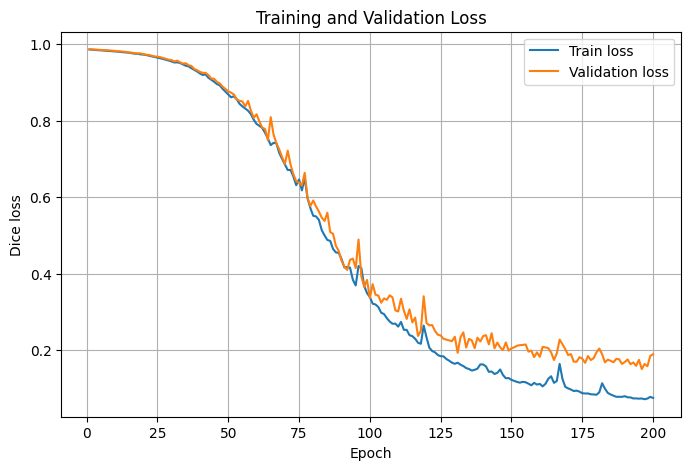

In [58]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, num_epochs + 1),
    train_losses,
    label="Train loss"
)

plt.plot(
    range(1, num_epochs + 1),
    val_losses,
    label="Validation loss"
)

plt.xlabel("Epoch")
plt.ylabel("Dice loss")
plt.title("Training and Validation Loss")

plt.legend()
plt.grid(True)

plt.show()

### 8. Apply model on test set

Finally, let's apply the model we trained on the test set to see how it performs

In [59]:
model.eval()

running_test_loss = 0.0

with torch.no_grad():

    for images, masks in test_loader:

        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)

        loss = criterion(masks, outputs)

        running_test_loss += loss.item()

test_loss = running_test_loss / len(test_loader)

print(f"Test loss: {test_loss:.4f}")

Test loss: 0.2346


We can also visually inspect one of the model predictions. Here, we display the central slice of a test volume together with the corresponding ground-truth segmentation and the predicted segmentation. This provides a simple 2D qualitative check of the model performance. To inspect the segmentation across the full 3D volume, the generated GIFs can be viewed in the output folder.

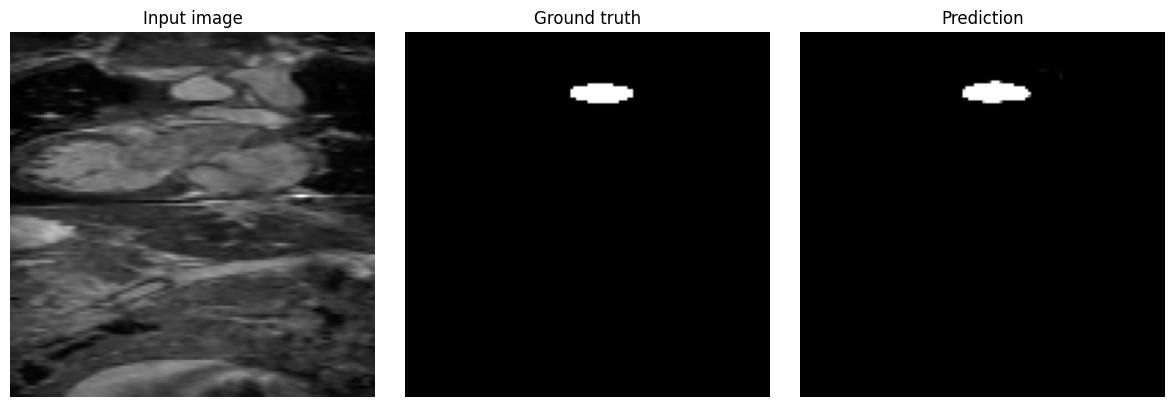

In [79]:
test_images, test_masks = next(iter(test_loader))

test_images = test_images.to(device)
test_masks = test_masks.to(device)

with torch.no_grad():
    test_predictions = model(test_images)

image = test_images[0, 0].cpu().numpy()
mask = test_masks[0, 0].cpu().numpy()
prediction = test_predictions[0, 0].cpu().numpy()

slice_idx = image.shape[0] // 2

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(image[slice_idx], cmap="gray")
axes[0].set_title("Input image")
axes[0].axis("off")

axes[1].imshow(mask[slice_idx], cmap="gray")
axes[1].set_title("Ground truth")
axes[1].axis("off")

axes[2].imshow(prediction[slice_idx], cmap="gray")
axes[2].set_title("Prediction")
axes[2].axis("off")

plt.tight_layout()
plt.show()

To save the model locally:

In [61]:
torch.save(model.state_dict(), "unet_trained_hvsmr.pth")

### References

[1] Pace, D.F., Contreras, H.T.M., Romanowicz, J. et al. HVSMR-2.0: A 3D cardiovascular MR dataset for whole-heart segmentation in congenital heart disease. Sci Data 11, 721 (2024). https://doi.org/10.1038/s41597-024-03469-9